#YB 미니 프로젝트3 - YB 1조
##'영화 관객수 예측 경진대회' 데이터셋에 회귀 알고리즘을 적용하기

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.base import clone

# 한글 폰트 설정 (Windows에서는 Malgun Gothic이 기본적으로 가장 안정적)
plt.rc('font', family='Malgun Gothic')

# 마이너스 폰트 깨짐 방지
plt.rc('axes', unicode_minus=False)


In [2]:
# 데이터 및 라이브러리 로딩
from google.colab import drive
drive.mount('/content/drive')
train=pd.read_csv('/content/drive/MyDrive/movies_train.csv')
test=pd.read_csv('/content/drive/MyDrive/movies_test.csv')
submission=pd.read_csv('/content/drive/MyDrive/submission.csv')

Mounted at /content/drive


In [3]:
train = train.drop(index=338).reset_index(drop=True)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           599 non-null    object 
 1   distributor     599 non-null    object 
 2   genre           599 non-null    object 
 3   release_time    599 non-null    object 
 4   time            599 non-null    int64  
 5   screening_rat   599 non-null    object 
 6   director        599 non-null    object 
 7   dir_prev_bfnum  269 non-null    float64
 8   dir_prev_num    599 non-null    int64  
 9   num_staff       599 non-null    int64  
 10  num_actor       599 non-null    int64  
 11  box_off_num     599 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.3+ KB


- 타겟 분포 + 로그 변환 EDA

<효과>

 - 왜 나중에 np.log1p로 타겟을 변환하는지 시각적 근거 생김

 - PPT에서 “타겟이 심하게 오른쪽 꼬리 → 로그 변환 필요” 스토리 만들기 좋음

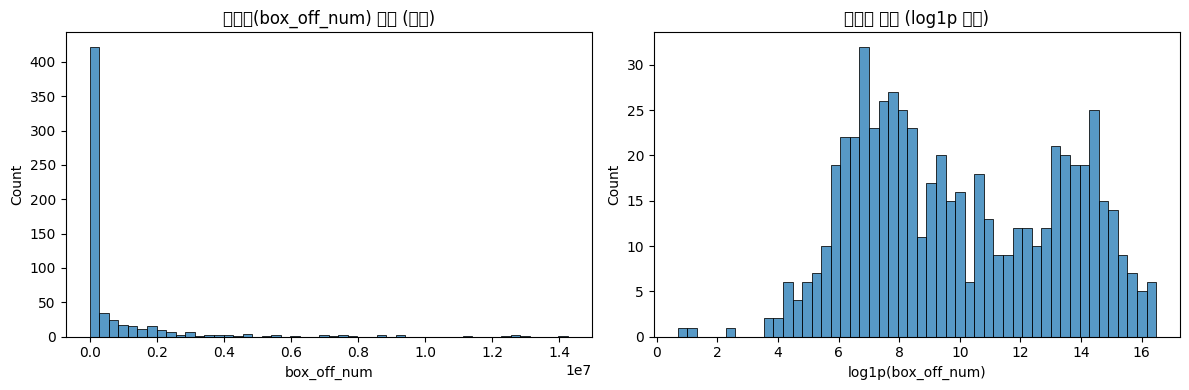

In [5]:
# (추가) 타겟 변수 분포 확인
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train['box_off_num'], bins=50)
plt.title("관객수(box_off_num) 분포 (원본)")
plt.xlabel("box_off_num")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['box_off_num']), bins=50)
plt.title("관객수 분포 (log1p 변환)")
plt.xlabel("log1p(box_off_num)")

plt.tight_layout()
plt.show()

In [6]:
train_x=train.drop('box_off_num',axis=1)
train_y=train.box_off_num
train_y_log = np.log1p(train_y)
n1=len(train_x)# 이상치 하나 제거!!!!
df=pd.concat([train_x,test],ignore_index=True) #train test 합쳐서 전처리 후 분리

#1. title
필요 없으므로 제거

In [7]:
df.drop('title',axis=1,inplace=True)

# 2. release_time
- datetime으로 변환
- 'year', 'month', 'weekday', 'is_weekend' 변수로 변환

In [8]:
# 1) 날짜 처리
train['release_dt'] = pd.to_datetime(train['release_time'])
test['release_dt'] = pd.to_datetime(test['release_time'])

train['year'] = train['release_dt'].dt.year
train['month'] = train['release_dt'].dt.month
train['weekday'] = train['release_dt'].dt.weekday
train['is_weekend'] = train['weekday'].isin([4, 5, 6]).astype(int)


test['year'] = test['release_dt'].dt.year
test['month'] = test['release_dt'].dt.month
test['weekday'] = test['release_dt'].dt.weekday
test['is_weekend'] = test['weekday'].isin([4, 5, 6]).astype(int)

- vacation 변수 추가
> month의 경우 숫자가 증가할수록 관객수가 증가하는 것이 아니라 방학인 달에서 box_off_num이 높게 나타나서 1,7,8,12월이 1 나머지가 0인 vacation변수로 할당

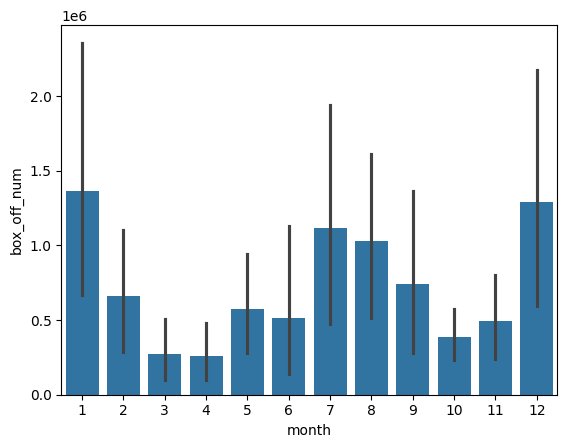

In [9]:
# vacation (기존 정의 유지)
sns.barplot(x=train['month'],y=train['box_off_num'],data=df)
train['vacation'] = train['month'].isin([1, 7, 8, 12]).astype(int)
test['vacation'] = test['month'].isin([1, 7, 8, 12]).astype(int)

<Axes: xlabel='vacation', ylabel='box_off_num'>

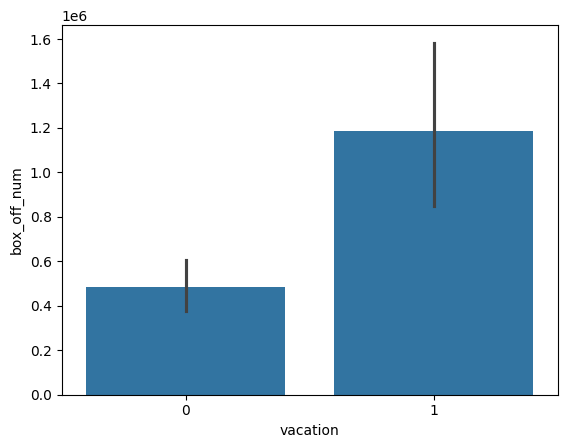

In [10]:
sns.barplot(x=train['vacation'],y=train['box_off_num'])

# 3.time
상영 시간이 110에서 150분 사이인 경우 관람객이 많으므로 sweet_spot이라는 변수로 할당(해당 길이이면 1 아니면 0)

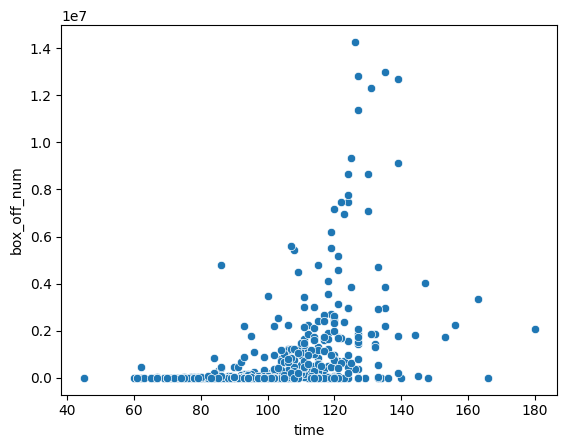

In [11]:
sns.scatterplot(x=train['time'],y=train['box_off_num'])
# sweet spot (상영시간 110~150분)
train['sweet_spot'] = train['time'].between(110, 150).astype(int)
test['sweet_spot'] = test['time'].between(110, 150).astype(int)

<Axes: xlabel='sweet_spot', ylabel='box_off_num'>

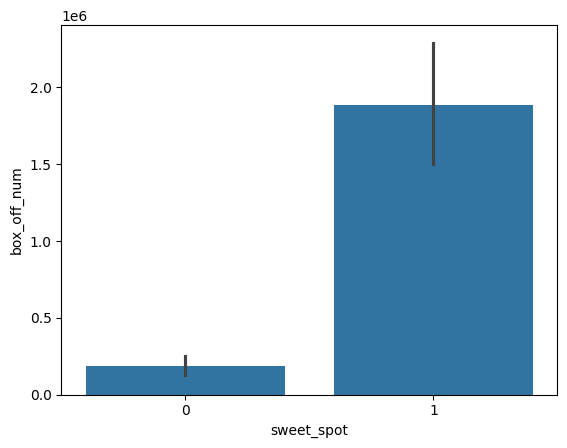

In [12]:
sns.barplot(x=train['sweet_spot'],y=train['box_off_num'])

# 4. distributor
배급사별로 모아서 관객 수의 중앙을 구하고, 성적이 좋은 순서대로 등수(숫자)를 매겨 'distributor_median_rank'라는 새로운 변수를 만든다.
test 데이터에 처음 보는 배급사가 나오면, 에러가 나지 않게 '평균 등수'로 빈칸을 채워준다.

<Axes: xlabel='distributor_median_rank', ylabel='box_off_num'>

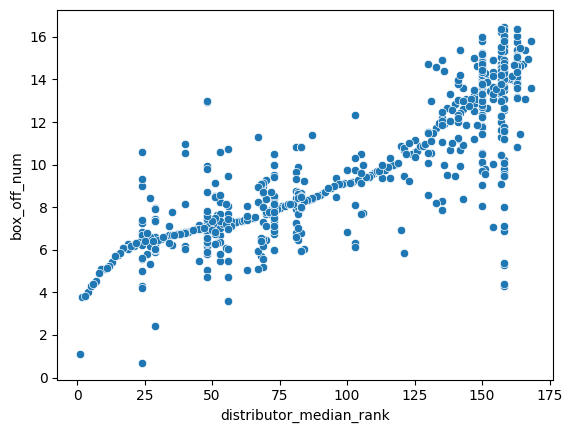

In [13]:
dist_rank = train.groupby('distributor')['box_off_num'].median().rank()
train['distributor_median_rank'] = train['distributor'].map(dist_rank)
test['distributor_median_rank'] = test['distributor'].map(dist_rank).fillna(dist_rank.mean())
sns.scatterplot(x=train['distributor_median_rank'],y=np.log1p(train['box_off_num']))

#5. dir_prev_num
감독이 신인이라면 새로 만든 new_director 변수에서 0을 할당하고, 신인이 아니라면 1을 할당한다.

In [14]:
train['new_director'] = (train['dir_prev_num'] == 0).astype(int)
test['new_director'] = (test['dir_prev_num'] == 0).astype(int)
test['new_director']

,new_director
0,0
1,0
2,0
3,0
4,0
...,...
238,0
239,1
240,1
241,0


#6. dir_prev_bfnum
dir_prev_bfnum에 로그를 씌운 값인 dir_prev_bfnum_log 변수를 만든다.

<Axes: xlabel='dir_prev_bfnum_log', ylabel='box_off_num'>

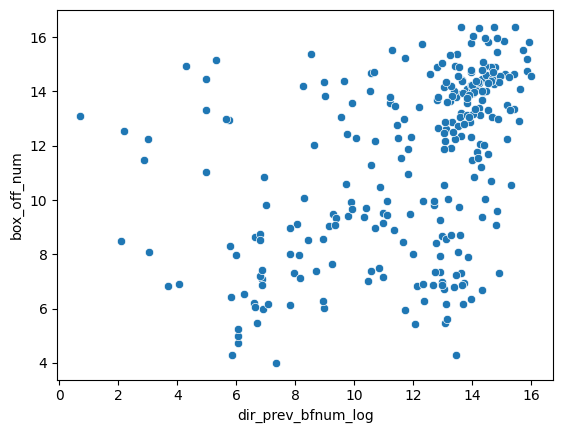

In [15]:
train['dir_prev_bfnum_log'] = np.log1p(train['dir_prev_bfnum'])
test['dir_prev_bfnum_log'] = np.log1p(test['dir_prev_bfnum'])

sns.scatterplot(x=train['dir_prev_bfnum_log'],y=np.log1p(train['box_off_num']))

#7. genre
장르별로 관객 수를 계산하고, 관객 수가 많은 순서대로 등수를 매겨 'genre_rank' 변수를 새로 만든다.
test 데이터에 처음 나오는 장르가 있다면, 평균 등수로 채워준다.


In [16]:
genre_rank = train.groupby('genre')['box_off_num'].mean().rank()
train['genre_rank'] = train['genre'].map(genre_rank)
test['genre_rank'] = test['genre'].map(genre_rank).fillna(genre_rank.mean())

#8. time, dir_prev_num, num_staff, num_actor, distributor_median_rank
숫자 데이터들에 로그를 적용해서 새로운 열(_log)을 만든다.
데이터 중에 0이 있으면 그냥 로그를 취했을 때 수학적으로 계산이 불가능해지기 때문에, 1을 더해서 안전하게 로그를 취한다.
숫자가 아주 작은 영화와 아주 큰 영화의 차이가 너무 심할 때, 이 차이를 줄여주어 데이터 분포를 정규분포에 가깝게 만들어주고 예측 성능이 올라간다.

In [17]:
for col in ['time', 'dir_prev_num', 'num_staff', 'num_actor', 'distributor_median_rank']:
    train[col + '_log'] = np.log1p(train[col])
    test[col + '_log'] = np.log1p(test[col])

#9. 로그 변환 전 원래 변수 제거




In [18]:
log_remove_cols = [ 'dir_prev_bfnum', 'time', 'dir_prev_num', 'num_staff', 'num_actor', 'distributor_median_rank']
train.drop(columns=log_remove_cols, inplace=True)
test.drop(columns=log_remove_cols, inplace=True)

#10. 숫자로 변환한 뒤, 더 이상 필요 없어진 문자 컬럼 제거

In [19]:
obj_cols = train.select_dtypes(include=['object']).columns
print("문자 컬럼 제거됨:", obj_cols.tolist())

train.drop(columns=obj_cols, inplace=True)
test.drop(columns=obj_cols, inplace=True)

문자 컬럼 제거됨: ['title', 'distributor', 'genre', 'release_time', 'screening_rat', 'director']


#11. 결측치 처리
- train에서 숫자 컬럼 NaN을 평균으로 채우고, test에서는 train 평균으로 채워서 데이터 누출을 방지한다.

In [20]:
num_cols_train = train.select_dtypes(include=[np.number]).columns
train[num_cols_train] = train[num_cols_train].fillna(train[num_cols_train].mean())

num_cols_test = test.select_dtypes(include=[np.number]).columns
test[num_cols_test] = test[num_cols_test].fillna(train[num_cols_train].mean())

#12. 데이터 분리
train 데이터에서 box_off_num(관객 수) 열만 쏙 뽑아서 y라는 변수에 저장한다.  train 데이터에서 box_off_num 열을 삭제하고, 남은 나머지 데이터들을 X라는 변수에 저장한다.

In [26]:
train

,box_off_num,release_dt,year,month,weekday,is_weekend,vacation,sweet_spot,new_director,dir_prev_bfnum_log,genre_rank,time_log,dir_prev_num_log,num_staff_log,num_actor_log,distributor_median_rank_log
0,23398,2012-11-22,2012,11,3,0,0,0,1,11.772466,11.0,4.574711,0.000000,4.521789,1.098612,5.017280
1,7072501,2015-11-19,2015,11,3,0,0,1,0,13.965312,12.0,4.875197,1.098612,5.961005,1.386294,5.099866
2,6959083,2013-06-05,2013,6,2,0,0,1,0,12.304905,11.0,4.820282,1.609438,5.840642,1.609438,5.099866
3,217866,2012-07-12,2012,7,3,0,1,0,0,10.081425,9.0,4.624973,1.098612,3.044522,1.945910,5.062595
4,483387,2010-11-04,2010,11,3,0,0,0,0,0.693147,9.0,4.691348,0.693147,5.529429,1.098612,5.117994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,1475091,2014-08-13,2014,8,2,0,1,1,0,8.251664,8.0,4.718499,0.693147,6.236370,2.079442,5.062595
595,1716438,2013-03-14,2013,3,3,0,0,1,0,13.114456,8.0,4.852030,0.693147,5.659482,1.945910,5.099866
596,2475,2010-09-30,2010,9,3,0,0,0,1,11.772466,7.0,4.605170,0.000000,4.820282,1.609438,3.891820
597,2192525,2015-05-14,2015,5,3,0,0,0,1,11.772466,12.0,4.634729,0.000000,6.068426,1.609438,5.068904


In [34]:
y = train['box_off_num']
X = train.drop(['box_off_num','release_dt'], axis=1)
test = train.drop(['box_off_num','release_dt'], axis=1)

#13. 스케일링

In [35]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test)

train_y_log = np.log1p(y)

#14. 회귀 모델 정의
- 1. 선행 및 커널 기반 모델
  - 라쏘, 엘라스틱넷, 커널릿지 활용
- 2. 부스팅 모델
  - XGBRegressor, LGBMRegressor, HistGradientBoostingRegressor 활용
- 3. 엑스트라 트리 회귀 모델

In [36]:
# Base models
lasso = Lasso(alpha=0.0003, random_state=42)
ENet = ElasticNet(alpha=0.0005, l1_ratio=0.9)
KRR = KernelRidge(alpha=0.6, kernel='rbf')

model_xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8
)

model_lgb = lgb.LGBMRegressor(
    objective='regression',
    num_leaves=31,
    learning_rate=0.03,
    n_estimators=3000,
    max_bin=255,
    bagging_fraction=0.8,
    bagging_freq=5,
    feature_fraction=0.8,
    min_data_in_leaf=20,
    min_sum_hessian_in_leaf=5,
    random_state=42
)

model_hgb = HistGradientBoostingRegressor(max_depth=6, max_iter=600)

model_et  = ExtraTreesRegressor(n_estimators=500, max_depth=None, random_state=42)


#15. 스태킹
Averaged Stacking 방식: 교차 검증 과정에서 만들어진 모델들의 예측값을 평균 내어 스태킹을 수행함

In [37]:
class StackingAveragedModels:
    def __init__(self, base_models, meta_model, n_folds=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds

    def fit(self, X, y):
        self.base_models_ = [list() for x in self.base_models]
        self.meta_model_ = clone(self.meta_model)
        kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=42)

        out_of_fold_predictions = np.zeros((X.shape[0], len(self.base_models)))

        for i, model in enumerate(self.base_models):
            for train_idx, val_idx in kfold.split(X, y):
                instance = clone(model)
                self.base_models_[i].append(instance)
                instance.fit(X[train_idx], y[train_idx])
                y_pred = instance.predict(X[val_idx])
                out_of_fold_predictions[val_idx, i] = y_pred

        self.meta_model_.fit(out_of_fold_predictions, y)
        return self

    def predict(self, X):
        meta_features = np.column_stack([
            np.column_stack([model.predict(X) for model in models]).mean(axis=1)
            for models in self.base_models_ ])
        return self.meta_model_.predict(meta_features)

#16. 개별 모델 학습 및 예측

In [38]:
stacked_averaged_models = StackingAveragedModels(
    base_models=(ENet, KRR, lasso),
    meta_model=lasso)

# 각 모델 log 예측
stacked_averaged_models.fit(X_scaled, train_y_log)
stacked_log = stacked_averaged_models.predict(test_scaled)

model_xgb.fit(X_scaled, train_y_log)
xgb_log = model_xgb.predict(test_scaled)

model_lgb.fit(X_scaled, train_y_log)
lgb_log = model_lgb.predict(test_scaled)

model_hgb.fit(X_scaled, train_y_log)
hgb_log = model_hgb.predict(test_scaled)

model_et.fit(X_scaled, train_y_log)
et_log = model_et.predict(test_scaled)


[LightGBM] [Warning] min_sum_hessian_in_leaf is set=5, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=5, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] featur

- LightGBM Feature Importance

<효과>

- “우리 모델은 어떤 피처를 중요하게 본다”를 한 장으로 보여줌

- 발표에서 vacation, genre_rank, _log 피처의 역할 설명할 때 매우 유용

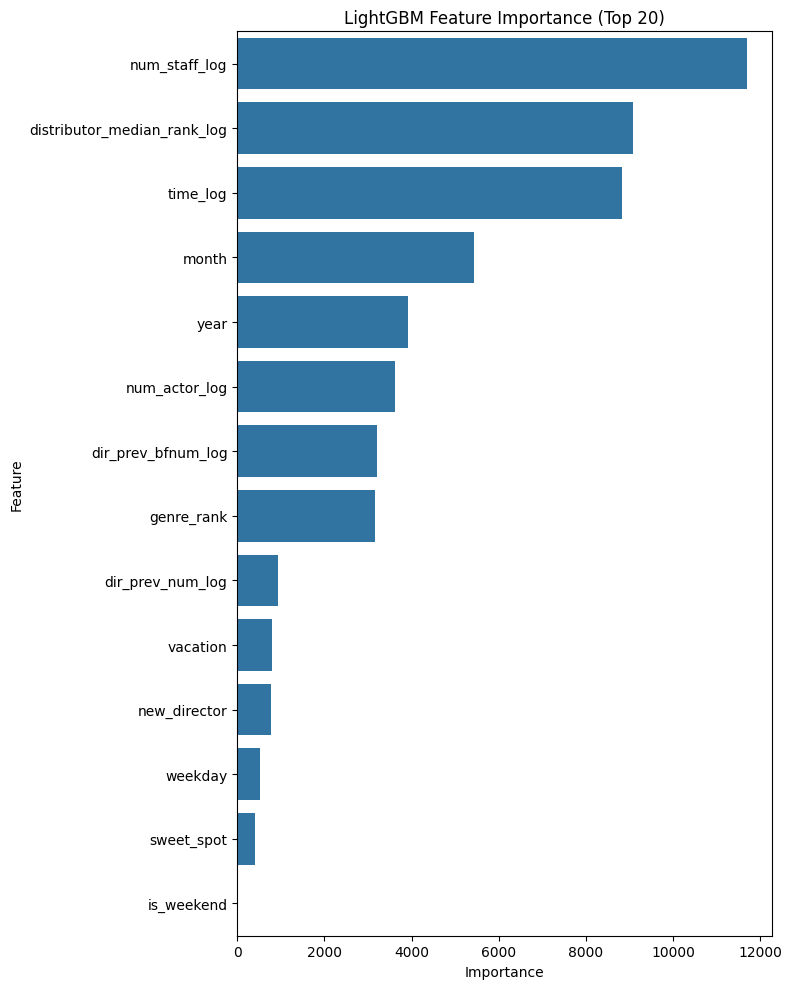

In [43]:
# (추가) LightGBM Feature Importance
lgb_importances = model_lgb.feature_importances_
feature_names = X.columns

fi = pd.Series(lgb_importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=fi.values[:20], y=fi.index[:20])
plt.title("LightGBM Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


- 실제값 vs 예측값 시각화

<효과>

- “대체로 예측이 실제와 얼마나 잘 맞는지” 직관적으로 보여줌

- PPT에서 모델 성능 부분에 이 그림 하나만 있어도 설명이 풍부해짐
(딱히 점수 안 적어도, 그림으로 설득 가능)

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=5, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


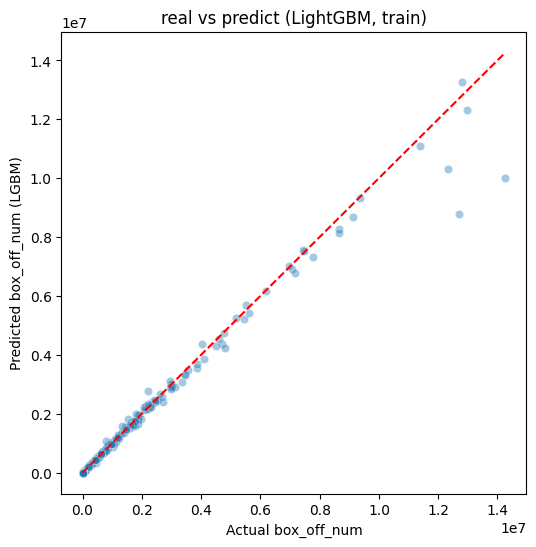

In [42]:
# (추가) train 데이터 기준 실제값 vs 예측값 (LightGBM)
train_pred_log = model_lgb.predict(X_scaled)
train_pred = np.expm1(train_pred_log)   # 로그 역변환

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y, y=train_pred, alpha=0.4)
min_val = min(y.min(), train_pred.min())
max_val = max(y.max(), train_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual box_off_num")
plt.ylabel("Predicted box_off_num (LGBM)")
plt.title("real vs predict (LightGBM, train)")
plt.show()


#17. 앙상블
- 위에서 구한 5개 모델의 예측값을 모두 더한 뒤 5로 나누어 산술 평균을 구하는 단순 평균 앙상블 방법을 사용한다.
- 결과값에 로그 변환 역산을 해준다.

In [40]:
ensemble_log = (stacked_log + xgb_log + lgb_log + hgb_log + et_log) / 5
final_pred = np.expm1(ensemble_log)

#18. 제출 데이터 생성

In [46]:
submission['box_off_num'] = final_pred
submission.to_csv("bestmodel_PATCH.csv", index=False)
print("Saved bestmodel_PATCH.csv")

ValueError: Length of values (599) does not match length of index (243)